# Exercise 2 — Multiple Linear Regression for Body Weight

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [2]:
DATA_URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv"
df = pd.read_csv(DATA_URL, sep=";")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (544, 4)


,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


In [3]:
df = df.rename(columns={
    "height": "Height_cm",
    "weight": "Weight_kg",
    "age": "Age",
    "male": "Male"
})

df["Gender"] = df["Male"].map({1: "Male", 0: "Female"})
df["Height"] = df["Height_cm"] / 100
model_df = df[["Weight_kg", "Height", "Age", "Gender"]].copy()

display(model_df.head())
display(model_df.isnull().sum())
display(model_df.describe(include="all").T)

,Weight_kg,Height,Age,Gender
0,47.825606,1.51765,63.0,Male
1,36.485807,1.39700,63.0,Female
2,31.864838,1.36525,65.0,Female
3,53.041914,1.56845,41.0,Male
4,41.276872,1.45415,51.0,Female


,0
Weight_kg,0
Height,0
Age,0
Gender,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Weight_kg,544.0,NaN,NaN,NaN,35.610618,14.719178,4.252425,22.007717,40.057844,47.209005,62.992589
Height,544.0,NaN,NaN,NaN,1.382636,0.276024,0.53975,1.25095,1.4859,1.5748,1.7907
Age,544.0,NaN,NaN,NaN,29.344393,20.746888,0.0,12.0,27.0,43.0,88.0
Gender,544,2,Female,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN


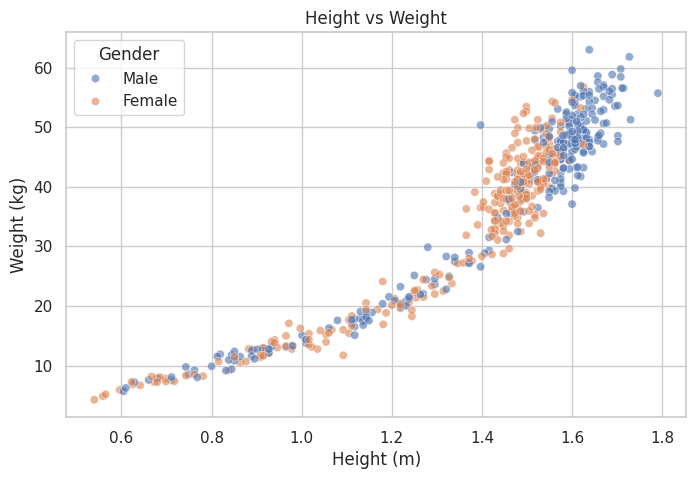

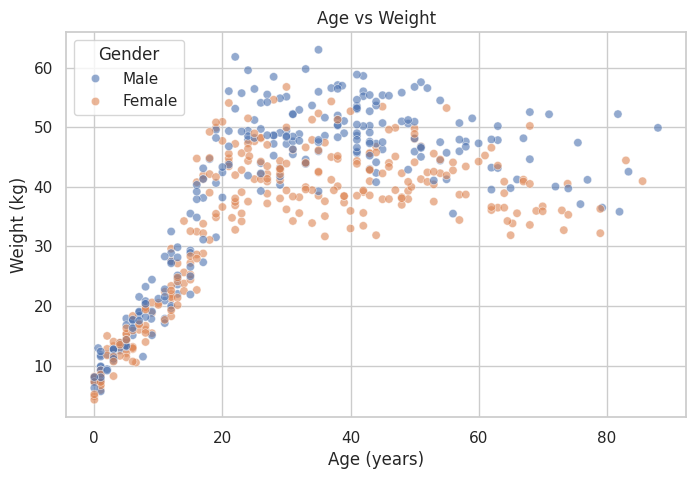

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=model_df, x="Height", y="Weight_kg", hue="Gender", alpha=0.6)
plt.title("Height vs Weight")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=model_df, x="Age", y="Weight_kg", hue="Gender", alpha=0.6)
plt.title("Age vs Weight")
plt.xlabel("Age (years)")
plt.ylabel("Weight (kg)")
plt.show()

In [5]:
X = model_df[["Height", "Age", "Gender"]]
y = model_df["Weight_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 435
Testing samples: 109


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("gender", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Gender"])
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [7]:
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [8]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Weight (kg)": y_test.values,
    "Predicted Weight (kg)": y_pred
})

display(results.head(10))

,Actual Weight (kg),Predicted Weight (kg)
0,55.394923,48.618674
1,48.137451,49.841546
2,43.431434,41.182960
3,41.050076,45.720633
4,8.051258,2.950529
5,12.927372,12.402175
6,53.098613,46.997076
7,47.286966,44.161405
8,50.263663,47.420085
9,47.485413,46.097486


In [9]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} kg")
print(f"RMSE: {rmse:.2f} kg")
print(f"R² Score: {r2:.4f}")

MAE: 3.99 kg
RMSE: 4.83 kg
R² Score: 0.8979


In [10]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

display(coef_df)
print("Intercept:", model.named_steps["regressor"].intercept_)

,Feature,Coefficient
0,gender__Gender_Male,0.749867
1,remainder__Height,46.327360
2,remainder__Age,0.063210


Intercept: -30.74735580571879


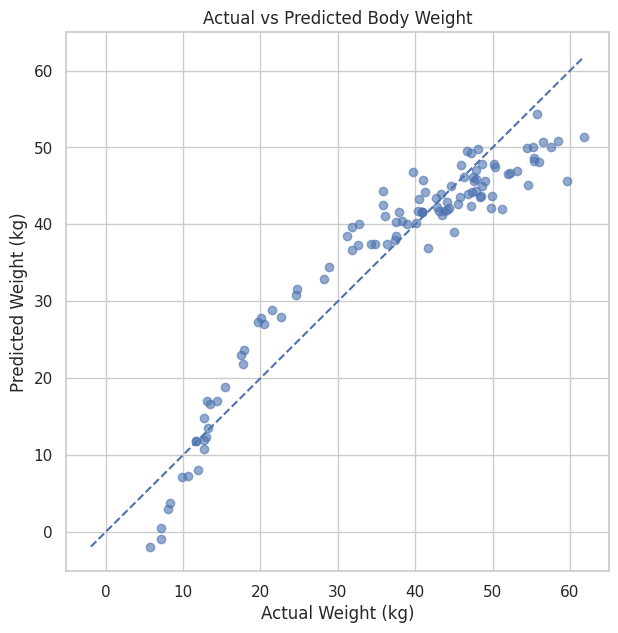

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs Predicted Body Weight")
plt.xlabel("Actual Weight (kg)")
plt.ylabel("Predicted Weight (kg)")
plt.show()

In [12]:
new_person = pd.DataFrame({
    "Height": [1.75],
    "Age": [30],
    "Gender": ["Male"]
})

predicted_weight = model.predict(new_person)[0]
print(f"Predicted body weight: {predicted_weight:.2f} kg")

Predicted body weight: 52.97 kg
